Contratos disponibles: ['CCH25', 'CCH26', 'CCH27', 'CCK25', 'CCK26', 'CCK27', 'CCN25', 'CCN26', 'CCN27', 'CCU25', 'CCU26', 'CCU27', 'CCZ25', 'CCZ26', 'CCZ27', 'SBH26', 'SBH27', 'SBH4', 'SBH5', 'SBH6', 'SBH7', 'SBH8', 'SBK26', 'SBK4', 'SBK5', 'SBK6', 'SBK7', 'SBK8', 'SBN26', 'SBN4', 'SBN5', 'SBN6', 'SBN7', 'SBN8', 'SBV26', 'SBV4', 'SBV5', 'SBV6', 'SBV7', 'ZCH25', 'ZCH26', 'ZCH27', 'ZCH28', 'ZCK25', 'ZCK26', 'ZCK27', 'ZCN25', 'ZCN26', 'ZCN27', 'ZCN28', 'ZCN29', 'ZCU25', 'ZCU26', 'ZCU27', 'ZCZ25', 'ZCZ26', 'ZCZ27', 'ZCZ28', 'ZCZ29']


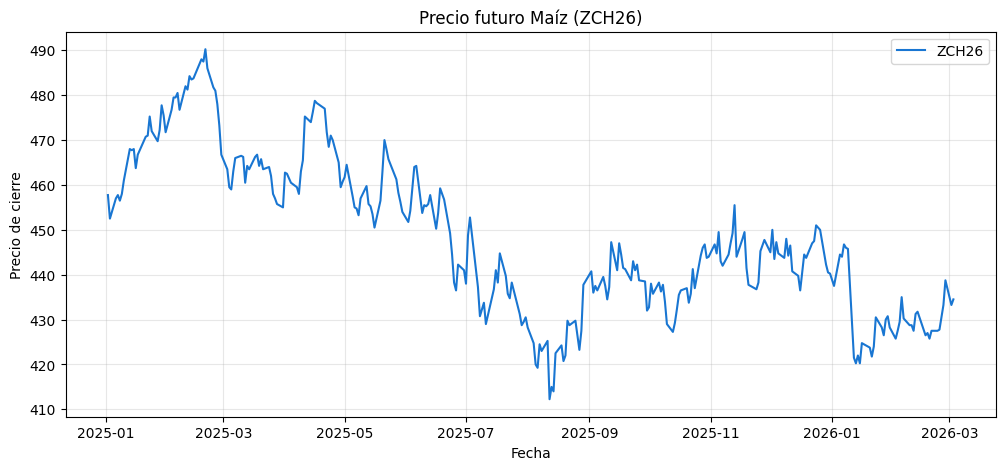

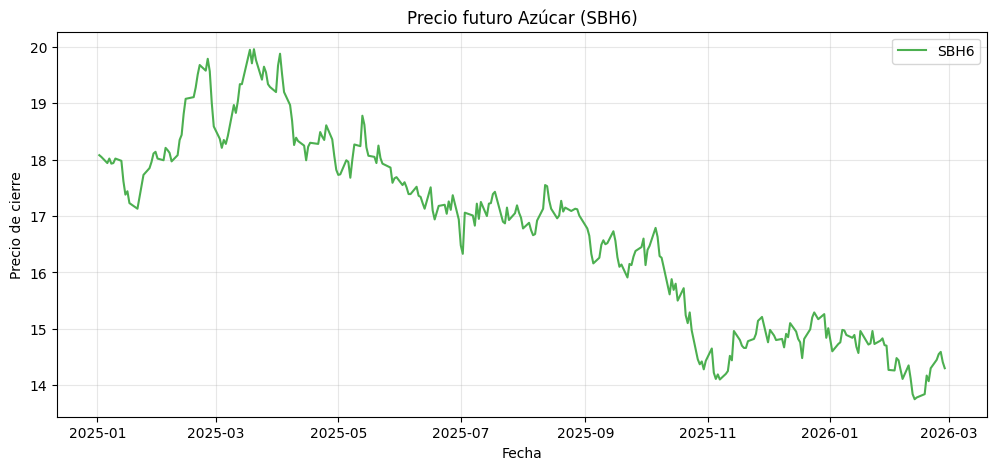

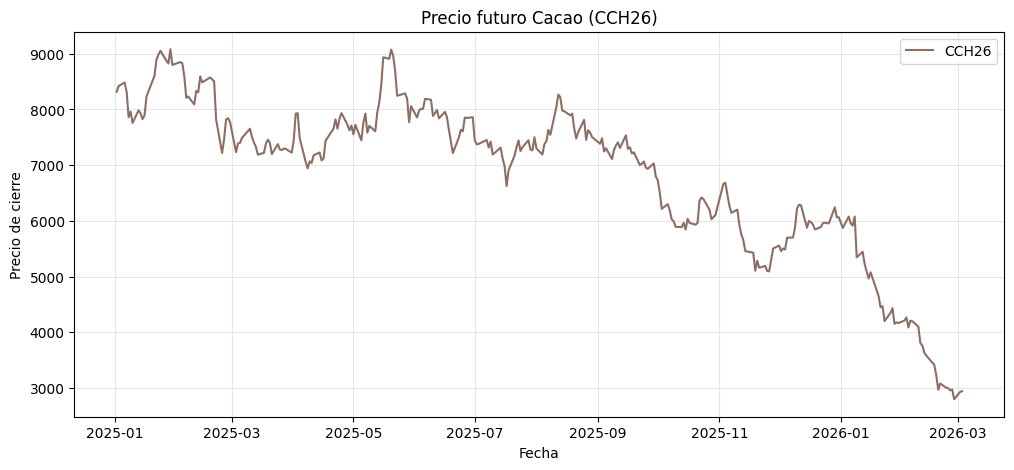

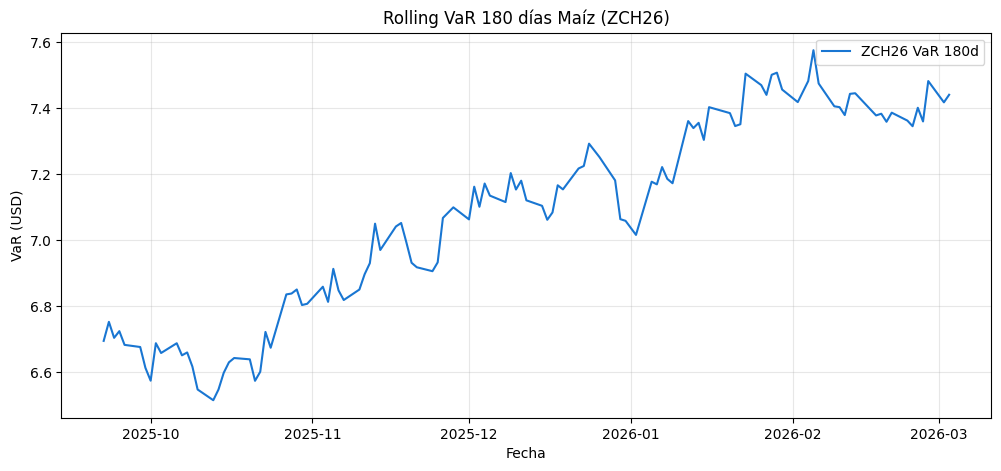

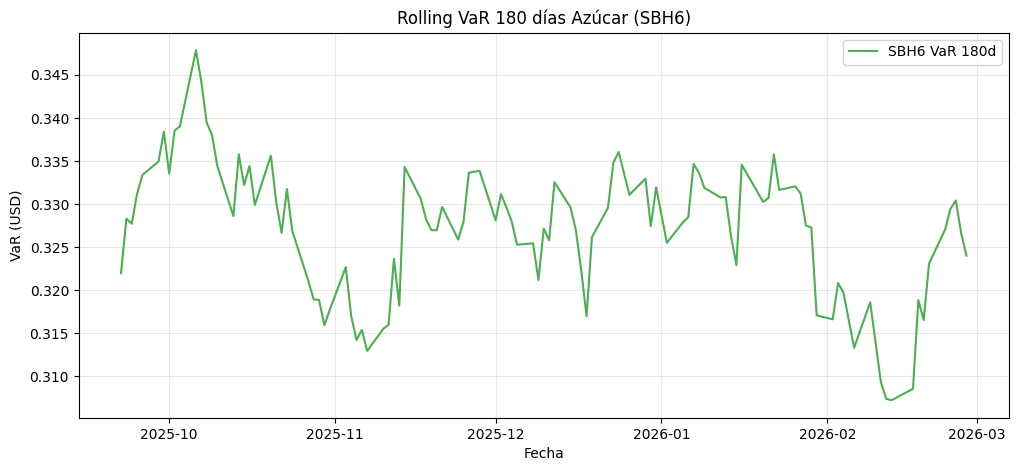

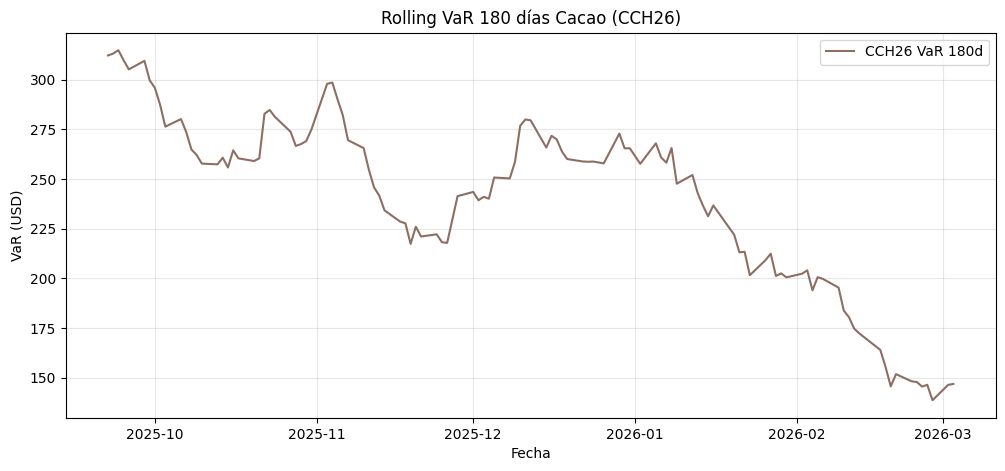

In [2]:
# ROLLING VAR EN USD PARA CONTRATOS FUTUROS DE AZUCAR, MAIZ Y CACAO
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ======================== CONFIG ========================
JSON_PATHS = [
    r"C:\Users\DanielAristizabal\Saman\Banca de Inversión - Documents\Super de Alimentos\Gestión de riesgo\Data\data_sb.json",
    r"C:\Users\DanielAristizabal\Saman\Banca de Inversión - Documents\Super de Alimentos\Gestión de riesgo\Data\data_zc1.json",
    r"C:\Users\DanielAristizabal\Saman\Banca de Inversión - Documents\Super de Alimentos\Gestión de riesgo\Data\data_cc.json",
]

CONTRACT_ZC = "ZCH26"  # Maíz
CONTRACT_SB = "SBH6"   # Azúcar (formato 1 dígito)
CONTRACT_CC = "CCH26"  # Cacao

ROLLING_WINDOW = 180
VAR_ALPHA = 0.95
# =======================================================

def load_contract_series(json_path: str) -> pd.DataFrame:
    with open(json_path, "r", encoding="utf-8") as f:
        obj = json.load(f)

    rows = []
    for contract, recs in obj.items():
        if not isinstance(recs, list):
            continue
        for r in recs:
            try:
                rows.append({
                    "date": pd.to_datetime(r["date"]),
                    "contract": contract,
                    "close": float(r["close"])
                })
            except Exception:
                continue

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(f"No hay datos validos en {json_path}")
    return df

def get_series(df: pd.DataFrame, contract: str) -> pd.Series:
    s = (df[df["contract"] == contract]
         .sort_values("date")
         .drop_duplicates(subset=["date"], keep="last")
         .set_index("date")["close"])
    if s.empty:
        raise ValueError(f"No hay datos para {contract}")
    return s

def rolling_var_usd_from_price(price_series: pd.Series, window: int = 180, alpha: float = 0.95) -> pd.Series:
    returns = np.log(price_series / price_series.shift(1)).dropna()
    rolling_var = returns.rolling(window).var()
    z = {0.90: 1.2816, 0.95: 1.6449, 0.975: 1.96, 0.99: 2.3263}.get(alpha, 1.6449)
    var_usd = z * np.sqrt(rolling_var) * price_series.loc[rolling_var.index]
    return var_usd

# --------------------- CARGA DATOS ---------------------
df_all = pd.concat([load_contract_series(p) for p in JSON_PATHS], ignore_index=True)

# Mostrar contratos disponibles
print("Contratos disponibles:", sorted(df_all["contract"].unique()))

zc_series = get_series(df_all, CONTRACT_ZC)
sb_series = get_series(df_all, CONTRACT_SB)
cc_series = get_series(df_all, CONTRACT_CC)

# --------------------- GRAFICAS PRECIOS ---------------------
plt.figure(figsize=(12, 5))
plt.plot(zc_series.index, zc_series, label=CONTRACT_ZC, color='#1976D2')
plt.title(f"Precio futuro Maíz ({CONTRACT_ZC})")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(sb_series.index, sb_series, label=CONTRACT_SB, color='#4CAF50')
plt.title(f"Precio futuro Azúcar ({CONTRACT_SB})")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(cc_series.index, cc_series, label=CONTRACT_CC, color='#8D6E63')
plt.title(f"Precio futuro Cacao ({CONTRACT_CC})")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --------------------- ROLLING VAR (USD) ---------------------
zc_var = rolling_var_usd_from_price(zc_series, window=ROLLING_WINDOW, alpha=VAR_ALPHA)
sb_var = rolling_var_usd_from_price(sb_series, window=ROLLING_WINDOW, alpha=VAR_ALPHA)
cc_var = rolling_var_usd_from_price(cc_series, window=ROLLING_WINDOW, alpha=VAR_ALPHA)

plt.figure(figsize=(12, 5))
plt.plot(zc_var.index, zc_var, label=f"{CONTRACT_ZC} VaR 180d", color='#1976D2')
plt.title(f"Rolling VaR 180 días Maíz ({CONTRACT_ZC})")
plt.xlabel("Fecha")
plt.ylabel("VaR (USD)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(sb_var.index, sb_var, label=f"{CONTRACT_SB} VaR 180d", color='#4CAF50')
plt.title(f"Rolling VaR 180 días Azúcar ({CONTRACT_SB})")
plt.xlabel("Fecha")
plt.ylabel("VaR (USD)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(cc_var.index, cc_var, label=f"{CONTRACT_CC} VaR 180d", color='#8D6E63')
plt.title(f"Rolling VaR 180 días Cacao ({CONTRACT_CC})")
plt.xlabel("Fecha")
plt.ylabel("VaR (USD)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



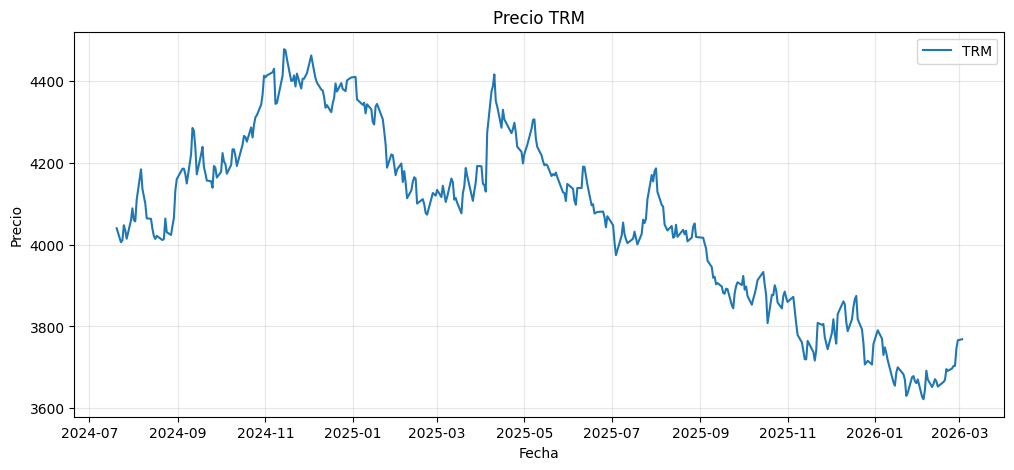

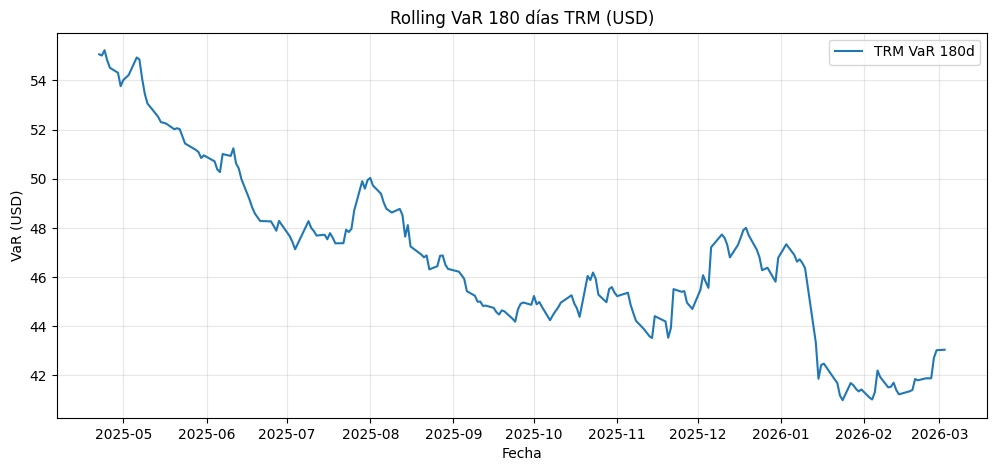

In [1]:
# ROLLING VAR 180 DIAS PARA TRM (USD)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ======================== CONFIG ========================
EXCEL_PATH = Path(r"C:\Users\DanielAristizabal\Saman\Banca de Inversión - Documents\Super de Alimentos\Gestión de riesgo\Data\trm.xlsx")
SHEET_NAME = "sheet1"

ROLLING_WINDOW = 180
VAR_ALPHA = 0.95
# =======================================================

def load_trm_series(path: Path, sheet: str) -> pd.Series:
    df = pd.read_excel(path, sheet_name=sheet)
    df.columns = [c.lower() for c in df.columns]

    if "fecha" not in df.columns or "precio" not in df.columns:
        raise ValueError(f"No se encuentran columnas 'fecha' y 'precio' en {path}")

    df["fecha"] = pd.to_datetime(df["fecha"])

    if df["precio"].dtype == object:
        df["precio"] = (df["precio"].astype(str)
                        .str.replace(".", "", regex=False)
                        .str.replace(",", ".", regex=False))

    df["precio"] = pd.to_numeric(df["precio"], errors="coerce")
    df = df.dropna(subset=["fecha", "precio"]).sort_values("fecha")

    return df.set_index("fecha")["precio"]

def rolling_var_usd_from_price(price_series: pd.Series, window: int = 180, alpha: float = 0.95) -> pd.Series:
    returns = np.log(price_series / price_series.shift(1)).dropna()
    rolling_var = returns.rolling(window).var()
    z = {0.90: 1.2816, 0.95: 1.6449, 0.975: 1.96, 0.99: 2.3263}.get(alpha, 1.6449)
    var_usd = z * np.sqrt(rolling_var) * price_series.loc[rolling_var.index]
    return var_usd

# --------------------- CARGA DATOS ---------------------
trm_series = load_trm_series(EXCEL_PATH, SHEET_NAME)

# --------------------- GRAFICA PRECIO ---------------------
plt.figure(figsize=(12, 5))
plt.plot(trm_series.index, trm_series, label="TRM")
plt.title("Precio TRM")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --------------------- ROLLING VAR (USD) ---------------------
trm_var = rolling_var_usd_from_price(trm_series, window=ROLLING_WINDOW, alpha=VAR_ALPHA)

plt.figure(figsize=(12, 5))
plt.plot(trm_var.index, trm_var, label="TRM VaR 180d")
plt.title("Rolling VaR 180 días TRM (USD)")
plt.xlabel("Fecha")
plt.ylabel("VaR (USD)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [2]:
# VISUALIZACIÓN: IMPACTO DE VOLATILIDAD EN ESTADO DE RESULTADOS Y EBITDA
# =============================================================================

import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ======================== CONFIGURACIÓN ========================
EXPOSICION_USD = 1_000_000  # Monto expuesto en USD (costos o ingresos)
TIPO_EXPOSICION = "costo"  # "costo" o "ingreso"
HORIZONTE_DIAS = 252  # 1 año (días de trading)

# Estado de Resultados Base (en COP)
INGRESOS_BASE = 15_000_000_000  # $15,000M COP
OTROS_COSTOS = 8_000_000_000   # Costos NO expuestos a USD
GASTOS_OPERACIONALES = 2_000_000_000  # $2,000M COP
# ===============================================================

# Usar datos del TRM ya cargados
returns = np.log(trm_series / trm_series.shift(1)).dropna()
vol_diaria = returns.std()
vol_anualizada = vol_diaria * np.sqrt(252)
TRM_ACTUAL = trm_series.iloc[-1]

# Cálculo del impacto en el costo expuesto
costo_usd_base = EXPOSICION_USD * TRM_ACTUAL

# Variación porcentual esperada a 1 año (±1σ, ±2σ)
var_1sigma = vol_anualizada
var_2sigma = vol_anualizada * 2

# Escenarios de TRM
trm_1sigma_up = TRM_ACTUAL * (1 + var_1sigma)
trm_1sigma_down = TRM_ACTUAL * (1 - var_1sigma)
trm_2sigma_up = TRM_ACTUAL * (1 + var_2sigma)
trm_2sigma_down = TRM_ACTUAL * (1 - var_2sigma)

# Impacto en el costo USD (en COP)
costo_1sigma_up = EXPOSICION_USD * trm_1sigma_up
costo_1sigma_down = EXPOSICION_USD * trm_1sigma_down
costo_2sigma_up = EXPOSICION_USD * trm_2sigma_up
costo_2sigma_down = EXPOSICION_USD * trm_2sigma_down

# Costo de ventas total = Otros costos + Costo expuesto a USD
costo_ventas_base = OTROS_COSTOS + costo_usd_base
costo_ventas_1sigma_up = OTROS_COSTOS + costo_1sigma_up
costo_ventas_1sigma_down = OTROS_COSTOS + costo_1sigma_down
costo_ventas_2sigma_up = OTROS_COSTOS + costo_2sigma_up
costo_ventas_2sigma_down = OTROS_COSTOS + costo_2sigma_down

# EBITDA = Ingresos - Costo de Ventas - Gastos Operacionales
ebitda_base = INGRESOS_BASE - costo_ventas_base - GASTOS_OPERACIONALES
ebitda_1sigma_up = INGRESOS_BASE - costo_ventas_1sigma_up - GASTOS_OPERACIONALES
ebitda_1sigma_down = INGRESOS_BASE - costo_ventas_1sigma_down - GASTOS_OPERACIONALES
ebitda_2sigma_up = INGRESOS_BASE - costo_ventas_2sigma_up - GASTOS_OPERACIONALES
ebitda_2sigma_down = INGRESOS_BASE - costo_ventas_2sigma_down - GASTOS_OPERACIONALES

print("=" * 70)
print("ANÁLISIS DE IMPACTO DE VOLATILIDAD USD/COP")
print("=" * 70)
print(f"TRM actual: ${TRM_ACTUAL:,.0f} COP/USD")
print(f"Volatilidad anualizada: {vol_anualizada:.2%}")
print(f"Exposición: ${EXPOSICION_USD:,.0f} USD = ${costo_usd_base/1e6:,.1f}M COP")
print("-" * 70)
print(f"EBITDA Base: ${ebitda_base/1e6:,.1f}M COP")
print(f"EBITDA +2σ:  ${ebitda_2sigma_up/1e6:,.1f}M COP ({(ebitda_2sigma_up-ebitda_base)/1e6:+,.1f}M)")
print(f"EBITDA -2σ:  ${ebitda_2sigma_down/1e6:,.1f}M COP ({(ebitda_2sigma_down-ebitda_base)/1e6:+,.1f}M)")
print("=" * 70)

# =============================================================================
# GRÁFICA MEJORADA
# =============================================================================

fig = plt.figure(figsize=(18, 9))
gs = GridSpec(2, 2, width_ratios=[1, 1.5], height_ratios=[1, 1], hspace=0.35, wspace=0.3)

# --- Panel 1: Estado de Resultados Simplificado ---
ax1 = fig.add_subplot(gs[:, 0])
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title("Estado de Resultados", fontsize=14, fontweight='bold', pad=20)

# Función helper para formatear millones
def fmt_m(val):
    return f"${val/1e9:,.1f}B" if abs(val) >= 1e9 else f"${val/1e6:,.0f}M"

# Dibujar tabla simplificada
lineas = [
    ("Ingresos", fmt_m(INGRESOS_BASE), "#2E7D32", False, None),
    ("(-) Costo de Ventas", fmt_m(costo_ventas_base), "#C62828", True, costo_usd_base),
    ("= Utilidad Bruta", fmt_m(INGRESOS_BASE - costo_ventas_base), "#1565C0", False, None),
    ("(-) Gastos Operacionales", fmt_m(GASTOS_OPERACIONALES), "#666666", False, None),
    ("= EBITDA", fmt_m(ebitda_base), "#1565C0", False, None),
]

y_pos = 8.5
for nombre, valor, color, es_expuesto, valor_usd in lineas:
    if es_expuesto:
        rect = mpatches.FancyBboxPatch((0.2, y_pos - 0.5), 9.6, 1.1,
                                        boxstyle="round,pad=0.05",
                                        facecolor='#FFF3E0', edgecolor='#E65100', linewidth=2)
        ax1.add_patch(rect)
        ax1.text(0.5, y_pos + 0.15, nombre, fontsize=11, va='center')
        ax1.text(5.5, y_pos + 0.15, valor, fontsize=11, va='center', ha='right', 
                color=color, fontweight='bold')
        ax1.text(0.7, y_pos - 0.35, f"↳ Incluye ${EXPOSICION_USD/1e6:.1f}M USD expuestos", 
                fontsize=9, va='center', color='#E65100', style='italic')
        ax1.text(9.5, y_pos, '⚠️', fontsize=14, va='center', ha='right')
    else:
        ax1.text(0.5, y_pos, nombre, fontsize=11, va='center', 
                fontweight='bold' if '=' in nombre else 'normal')
        ax1.text(5.5, y_pos, valor, fontsize=11, va='center', ha='right', 
                color=color, fontweight='bold')
    y_pos -= 1.5

ax1.text(5, 1.5, f"Volatilidad USD/COP: {vol_anualizada:.1%} anual", 
         fontsize=10, ha='center', fontweight='bold', color='#E65100')
ax1.text(5, 0.8, f"TRM: ${TRM_ACTUAL:,.0f} COP/USD", 
         fontsize=10, ha='center', color='#666666')

# --- Panel 2: Impacto en Costo (Barras Horizontales) ---
ax2 = fig.add_subplot(gs[0, 1])

escenarios = ['+2σ', '+1σ', 'Base', '-1σ', '-2σ']
costos = [costo_2sigma_up, costo_1sigma_up, costo_usd_base, costo_1sigma_down, costo_2sigma_down]
colores_costo = ['#D32F2F', '#FF7043', '#4CAF50', '#64B5F6', '#1976D2']
y_positions = [4, 3, 2, 1, 0]

bars = ax2.barh(y_positions, costos, color=colores_costo, height=0.65, edgecolor='white', linewidth=1.5)

for bar, val, esc in zip(bars, costos, escenarios):
    width = bar.get_width()
    diff = val - costo_usd_base
    
    # Valor dentro de la barra
    ax2.text(width - width*0.02, bar.get_y() + bar.get_height()/2,
             f'${val/1e6:,.0f}M', va='center', ha='right', fontsize=10, 
             fontweight='bold', color='white')
    
    if esc != 'Base':
        diff_text = f"+{diff/1e6:,.0f}M" if diff > 0 else f"{diff/1e6:,.0f}M"
        color_diff = '#B71C1C' if diff > 0 else '#0D47A1'
        ax2.text(width + costo_usd_base * 0.02, bar.get_y() + bar.get_height()/2,
                 diff_text, va='center', ha='left', fontsize=9, 
                 fontweight='bold', color=color_diff)

ax2.set_yticks(y_positions)
ax2.set_yticklabels(escenarios, fontsize=12, fontweight='bold')
ax2.set_xlabel('Costo en COP', fontsize=11)
ax2.set_title(f'Variación del Costo Expuesto a USD\n(${EXPOSICION_USD/1e6:.1f}M USD)', 
              fontsize=12, fontweight='bold')
ax2.axvline(x=costo_usd_base, color='#2E7D32', linestyle='--', linewidth=2, alpha=0.7)
ax2.grid(axis='x', alpha=0.3, linestyle=':')
ax2.set_xlim(0, costo_2sigma_up * 1.12)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:,.0f}M'))

# --- Panel 3: Impacto en EBITDA (MEJORADO) ---
ax3 = fig.add_subplot(gs[1, 1])

ebitdas = [ebitda_2sigma_up, ebitda_1sigma_up, ebitda_base, ebitda_1sigma_down, ebitda_2sigma_down]
colores_ebitda = ['#1976D2', '#64B5F6', '#4CAF50', '#FF7043', '#D32F2F']

# Calcular límites del eje X
min_ebitda = min(ebitdas)
max_ebitda = max(ebitdas)
x_min = min(0, min_ebitda * 1.1)
x_max = max_ebitda * 1.25

bars_ebitda = ax3.barh(y_positions, ebitdas, color=colores_ebitda, height=0.65, 
                        edgecolor='white', linewidth=1.5)

# Umbral para decidir si el texto va dentro o fuera de la barra
umbral_texto = max_ebitda * 0.25

for bar, val, esc, color in zip(bars_ebitda, ebitdas, escenarios, colores_ebitda):
    width = bar.get_width()
    diff = val - ebitda_base
    
    # Decidir posición del texto según tamaño de la barra
    if width > umbral_texto:
        # Texto DENTRO de la barra (barra suficientemente grande)
        ax3.text(width - max_ebitda*0.02, bar.get_y() + bar.get_height()/2,
                 f'${val/1e6:,.0f}M', va='center', ha='right', fontsize=10, 
                 fontweight='bold', color='white')
        x_diff = width + max_ebitda * 0.02
    else:
        # Texto FUERA de la barra (barra pequeña)
        ax3.text(width + max_ebitda*0.02, bar.get_y() + bar.get_height()/2,
                 f'${val/1e6:,.0f}M', va='center', ha='left', fontsize=10, 
                 fontweight='bold', color=color)
        x_diff = width + max_ebitda * 0.12
    
    # Diferencia y porcentaje
    if esc != 'Base':
        diff_text = f"+{diff/1e6:,.0f}M" if diff > 0 else f"{diff/1e6:,.0f}M"
        pct_change = (val - ebitda_base) / ebitda_base * 100
        pct_text = f"({pct_change:+.1f}%)"
        color_diff = '#0D47A1' if diff > 0 else '#B71C1C'
        ax3.text(x_diff, bar.get_y() + bar.get_height()/2,
                 f'{diff_text} {pct_text}', va='center', ha='left', fontsize=9, 
                 fontweight='bold', color=color_diff)

ax3.set_yticks(y_positions)
ax3.set_yticklabels(escenarios, fontsize=12, fontweight='bold')
ax3.set_xlabel('EBITDA en COP', fontsize=11)
ax3.set_title('Impacto en EBITDA\n(Efecto de la volatilidad USD/COP)', 
              fontsize=12, fontweight='bold')
ax3.axvline(x=ebitda_base, color='#2E7D32', linestyle='--', linewidth=2, alpha=0.7)
ax3.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
ax3.grid(axis='x', alpha=0.3, linestyle=':')
ax3.set_xlim(x_min, x_max)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:,.0f}M'))

plt.suptitle(f'Impacto de Volatilidad USD/COP en Estado de Resultados\nHorizonte: 1 año | Volatilidad: {vol_anualizada:.1%}', 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Resumen final
print("\n" + "=" * 70)
print("RESUMEN: RANGO DE VARIACIÓN DEL EBITDA POR VOLATILIDAD USD/COP")
print("=" * 70)
print(f"{'Escenario':<12} {'EBITDA':<15} {'Variación':<15} {'% vs Base':<10}")
print("-" * 70)
for esc, ebit in zip(escenarios, ebitdas):
    diff = ebit - ebitda_base
    pct = (ebit - ebitda_base) / ebitda_base * 100 if ebitda_base != 0 else 0
    print(f"{esc:<12} ${ebit/1e6:>10,.0f}M    {diff/1e6:>+10,.0f}M      {pct:>+6.1f}%")
print("=" * 70)

NameError: name 'trm_series' is not defined